In [1]:
import pandas as pd

df = pd.read_csv("winequality_main.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [2]:
print(df.shape)
print(df.columns)

(6497, 12)
Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')


In [3]:
X = df.drop("quality", axis=1)

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Text(0.5, 1.0, 'Dendrogram - Wine Dataset')

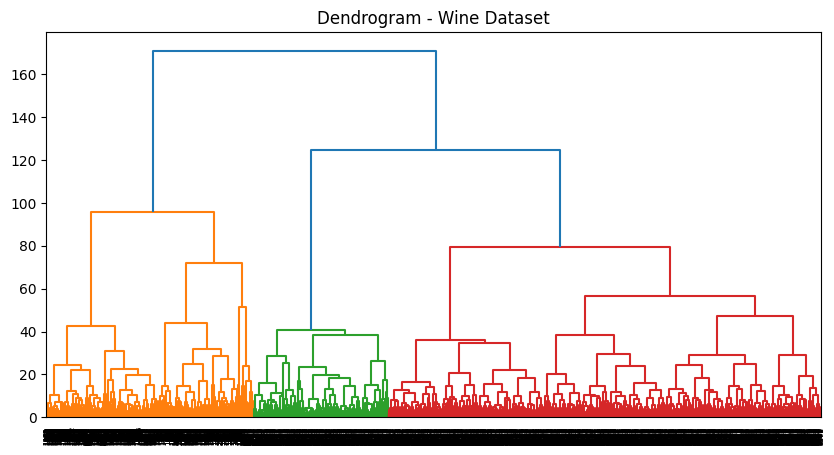

In [5]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10,5))
dendrogram(linked)
plt.title("Dendrogram - Wine Dataset")

Text(0.5, 1.0, 'Dendrogram - Wine Dataset')

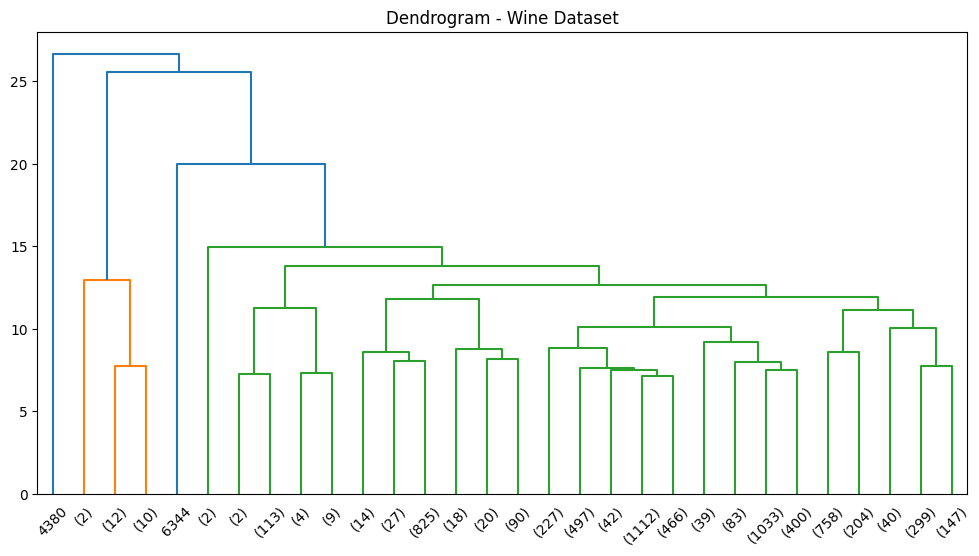

In [6]:
linked = linkage(X_scaled, method='complete')

plt.figure(figsize=(12,6))
dendrogram(linked, truncate_mode='lastp', p=30)
plt.title("Dendrogram - Wine Dataset")

In [7]:
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(n_clusters=3)
labels = model.fit_predict(X_scaled)

print(set(labels))

{np.int64(0), np.int64(1), np.int64(2)}


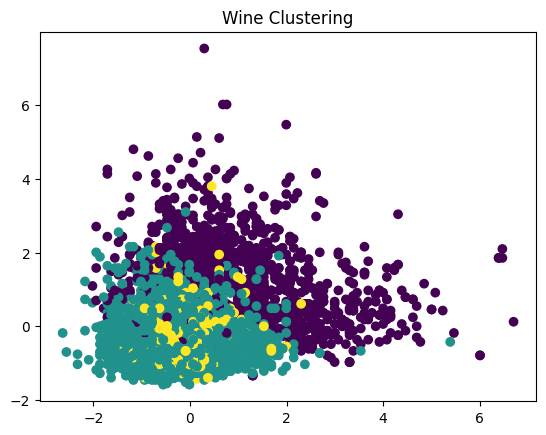

In [8]:
plt.figure()

plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels)

plt.title("Wine Clustering")
plt.show()

In [9]:
print("Number of clusters:", len(set(labels)))

Number of clusters: 3


Text(0.5, 1.0, 'Cluster Distribution')

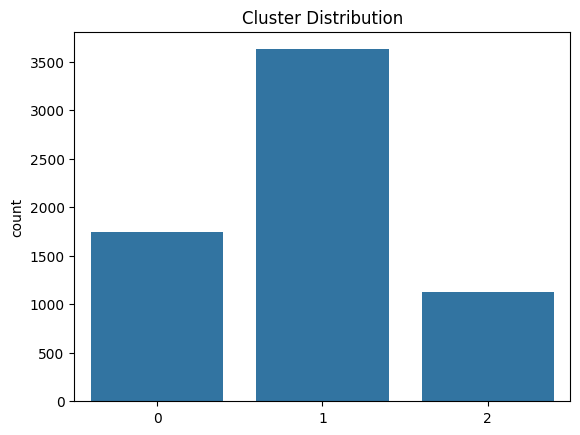

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=labels)
plt.title("Cluster Distribution")
